In [129]:
import pandas as pd
from IPython.core.display import HTML

# Creation

In [130]:
# Creating a Series with city names
city_series = pd.Series(["New York", "Los Angeles", "Chicago", "Houston", "Phoenix"])
city_series.to_frame(name="City")  # what happens in the back of jupyter notebook display(HTML(city_series.to_frame(name="City"))))

,City
0,New York
1,Los Angeles
2,Chicago
3,Houston
4,Phoenix


In [ ]:
# Creating a DataFrame with cities and number of inhabitants
city_data = pd.DataFrame({
    "City": city_series,
    "Location": ["North", "South", "Middle", "South", "South"],
    "Inhabitants": [8419000, 3980000, 2716000, 2328000, 1690000]
})

# Displaying the DataFrame as HTML
city_data  # what happens in the back of jupyter notebook display(HTML(city_data.to_html())))


,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000
2,Chicago,Middle,2716000
3,Houston,South,2328000
4,Phoenix,South,1690000


# Direct Access

In [132]:
display(city_data.loc[1])  # Selecting specific rows and columns
display(city_series.loc[1])
display(city_data.iloc[1,0])  # Selecting specific rows and columns using iloc
display(city_series.iloc[1])

display(city_data['City'])  # Creates a series from a DataFrame column
# Series has no columns, only index

City           Los Angeles
Location             South
Inhabitants        3980000
Name: 1, dtype: object

'Los Angeles'

'Los Angeles'

'Los Angeles'

0       New York
1    Los Angeles
2        Chicago
3        Houston
4        Phoenix
Name: City, dtype: object

# Frame Information

In [133]:
display(city_data.shape)
display(city_data.columns)
display(city_data.index)
display(city_data.dtypes)
display(city_data.info())

(5, 3)

Index(['City', 'Location', 'Inhabitants'], dtype='object')

RangeIndex(start=0, stop=5, step=1)

City           object
Location       object
Inhabitants     int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   City         5 non-null      object
 1   Location     5 non-null      object
 2   Inhabitants  5 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes


None

# Series Information

In [134]:
display(city_series.shape)
# no columns in series
display(city_series.index)
display(city_series.dtypes)
display(city_series.info())

(5,)

RangeIndex(start=0, stop=5, step=1)

dtype('O')

<class 'pandas.core.series.Series'>
RangeIndex: 5 entries, 0 to 4
Series name: None
Non-Null Count  Dtype 
--------------  ----- 
5 non-null      object
dtypes: object(1)
memory usage: 172.0+ bytes


None

# Filter

In [135]:
display(city_data[city_data['Inhabitants'] > 3000000])  # Filtering DataFrame rows based on a condition
display(city_data[(city_data['Inhabitants'] > 3000000) & (city_data['Location'].isin(["South"]))]) # Multiple conditions

,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000


,City,Location,Inhabitants
1,Los Angeles,South,3980000


# Analysis and Grouping

In [136]:
display(city_data.describe())  # Descriptive statistics for numerical columns

display(city_series.describe())  # Descriptive statistics for numerical columns

display(city_data.agg({'Inhabitants': ['sum', 'mean']}, axis=0)) # 0 default axis

display(city_data.groupby('Location').agg({'Inhabitants': ['sum', 'mean']}))  # Grouping by a column and aggregating


,Inhabitants
count,5.000000e+00
mean,3.826600e+06
std,2.699906e+06
min,1.690000e+06
25%,2.328000e+06
50%,2.716000e+06
75%,3.980000e+06
max,8.419000e+06


count            5
unique           5
top       New York
freq             1
dtype: object

,Inhabitants
sum,19133000.0
mean,3826600.0


Inhabitants           
                 sum       mean
Location                       
Middle       2716000  2716000.0
North        8419000  8419000.0
South        7998000  2666000.0

# Sorting

In [137]:
display(city_data)
display(city_data.sort_values('Inhabitants'))  # Sorting DataFrame by a column
display(city_data.sort_values('Inhabitants', ascending=False))  # Sorting DataFrame by a column in descending order)
display(city_data.sort_index())  # Sorting DataFrame by index is default
# sorting can be done in place or by creating a new DataFrame
city_data.sort_values('Inhabitants', ascending=True, inplace=True)  # Sorting DataFrame by a column in descending order
display(city_data)
city_data.sort_index(inplace=True)  # Sorting DataFrame by index is default
display(city_data)

,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000
2,Chicago,Middle,2716000
3,Houston,South,2328000
4,Phoenix,South,1690000


,City,Location,Inhabitants
4,Phoenix,South,1690000
3,Houston,South,2328000
2,Chicago,Middle,2716000
1,Los Angeles,South,3980000
0,New York,North,8419000


,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000
2,Chicago,Middle,2716000
3,Houston,South,2328000
4,Phoenix,South,1690000


,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000
2,Chicago,Middle,2716000
3,Houston,South,2328000
4,Phoenix,South,1690000


,City,Location,Inhabitants
4,Phoenix,South,1690000
3,Houston,South,2328000
2,Chicago,Middle,2716000
1,Los Angeles,South,3980000
0,New York,North,8419000


,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000
2,Chicago,Middle,2716000
3,Houston,South,2328000
4,Phoenix,South,1690000


# Data Join

In [138]:
city_data_area = pd.DataFrame({
    "City": city_series,
    "Area": [783.8, 1302, 606.1, 1651.1, 1340.6],
})

city_data_combined = pd.merge(city_data, city_data_area, on="City", how="inner")
display(city_data)

,City,Location,Inhabitants
0,New York,North,8419000
1,Los Angeles,South,3980000
2,Chicago,Middle,2716000
3,Houston,South,2328000
4,Phoenix,South,1690000


# Calculated column

In [139]:
city_data_copy = city_data_combined.copy()

city_data_copy['Inhabitants_Per_km2'] = city_data_copy['Inhabitants'] / city_data_copy['Area']
display(city_data_copy)

city_data_combined = city_data_combined.astype({
    'City': 'string',
    'Location': 'string',
    'Area': 'float64',
    'Inhabitants': 'int64'
})
display(city_data_combined.dtypes)
city_data_combined['Inhabitants_Per_km2'] = city_data_combined['Inhabitants'] / city_data_combined['Area']
display(city_data_combined)


,City,Location,Inhabitants,Area,Inhabitants_Per_km2
0,New York,North,8419000,783.8,10741.260526
1,Los Angeles,South,3980000,1302.0,3056.835637
2,Chicago,Middle,2716000,606.1,4481.108728
3,Houston,South,2328000,1651.1,1409.969112
4,Phoenix,South,1690000,1340.6,1260.629569


City           string[python]
Location       string[python]
Inhabitants             int64
Area                  float64
dtype: object

,City,Location,Inhabitants,Area,Inhabitants_Per_km2
0,New York,North,8419000,783.8,10741.260526
1,Los Angeles,South,3980000,1302.0,3056.835637
2,Chicago,Middle,2716000,606.1,4481.108728
3,Houston,South,2328000,1651.1,1409.969112
4,Phoenix,South,1690000,1340.6,1260.629569


# Write to File

In [140]:
city_data_combined.to_csv('city_data_combined.csv', index=False)
city_data_combined.to_parquet('city_data_combined.parquet', index=False)


# Read from File

In [141]:
city_data_combined = pd.read_csv('city_data_combined.csv')
display(city_data_combined)
display(city_data_combined.dtypes)

city_data_combined_parquet = pd.read_parquet('city_data_combined.parquet')
display(city_data_combined_parquet)
display(city_data_combined.dtypes)

with open('city_data_combined.csv', 'r') as file:
    data = file.read()
    display(data)


,City,Location,Inhabitants,Area,Inhabitants_Per_km2
0,New York,North,8419000,783.8,10741.260526
1,Los Angeles,South,3980000,1302.0,3056.835637
2,Chicago,Middle,2716000,606.1,4481.108728
3,Houston,South,2328000,1651.1,1409.969112
4,Phoenix,South,1690000,1340.6,1260.629569


City                    object
Location                object
Inhabitants              int64
Area                   float64
Inhabitants_Per_km2    float64
dtype: object

,City,Location,Inhabitants,Area,Inhabitants_Per_km2
0,New York,North,8419000,783.8,10741.260526
1,Los Angeles,South,3980000,1302.0,3056.835637
2,Chicago,Middle,2716000,606.1,4481.108728
3,Houston,South,2328000,1651.1,1409.969112
4,Phoenix,South,1690000,1340.6,1260.629569


City                    object
Location                object
Inhabitants              int64
Area                   float64
Inhabitants_Per_km2    float64
dtype: object

'City,Location,Inhabitants,Area,Inhabitants_Per_km2\nNew York,North,8419000,783.8,10741.260525644298\nLos Angeles,South,3980000,1302.0,3056.8356374807986\nChicago,Middle,2716000,606.1,4481.108727932684\nHouston,South,2328000,1651.1,1409.9691115014234\nPhoenix,South,1690000,1340.6,1260.629568849769\n'

# Plot

In [142]:
import matplotlib.pyplot as plt

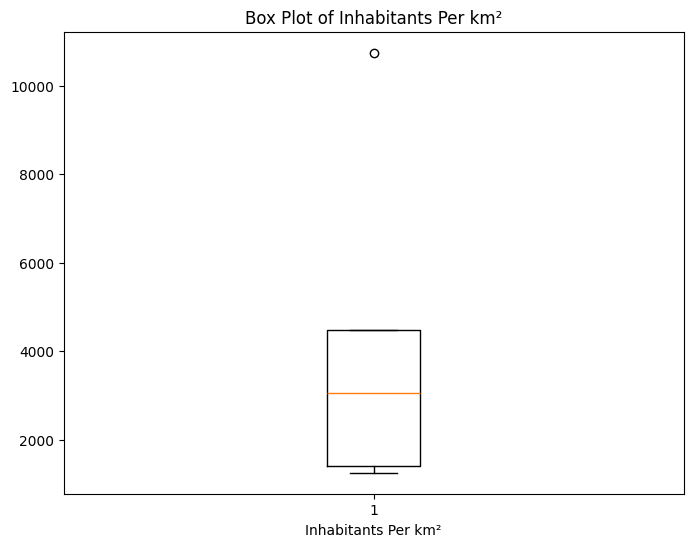

In [143]:

# Plotting a box plot for the 'Inhabitants_Per_km2' column
plt.figure(figsize=(8, 6))
plt.boxplot(city_data_combined['Inhabitants_Per_km2'])
plt.title('Box Plot of Inhabitants Per km²')
plt.xlabel('Inhabitants Per km²')
plt.show()

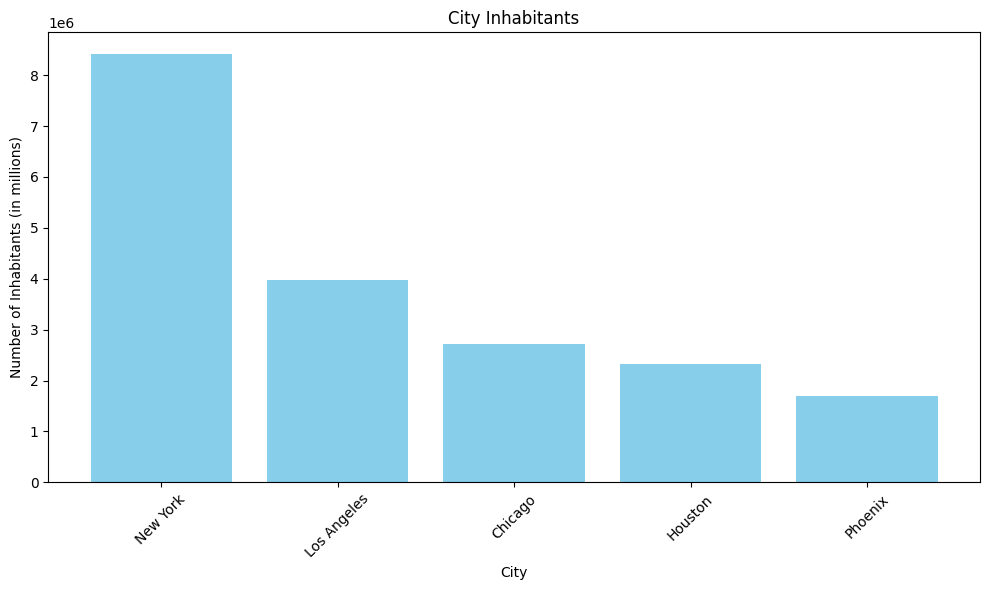

In [144]:
plt.figure(figsize=(10, 6))
plt.bar(city_data['City'], city_data['Inhabitants'], color='skyblue')
plt.title('City Inhabitants')
plt.xlabel('City')
plt.ylabel('Number of Inhabitants (in millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

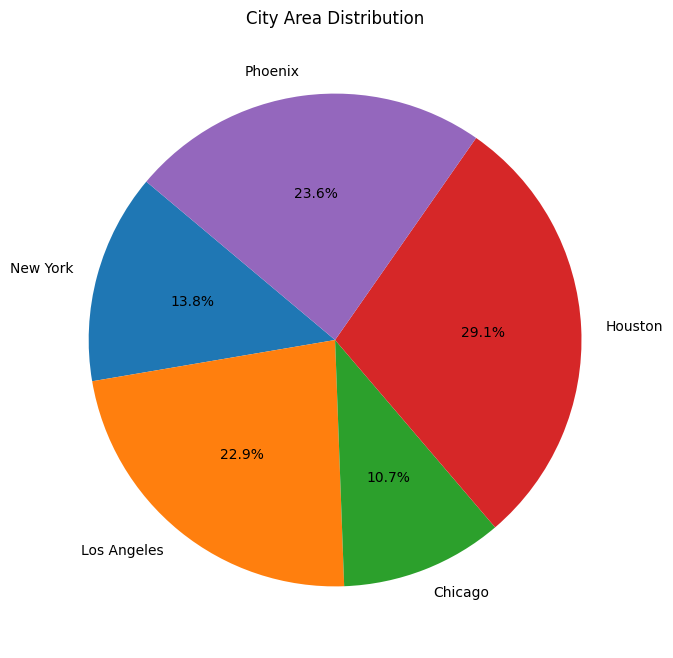

In [145]:
plt.figure(figsize=(8, 8))
plt.pie(city_data_area['Area'], labels=city_data_area['City'], autopct='%1.1f%%', startangle=140)
plt.title('City Area Distribution')
plt.show()